In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Loading and Normalizing CIFAR-10
   The CIFAR-10 dataset contains 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

In [2]:
def get_train_valid_loader(data_dir,
                               batch_size,
                               augment,
                               random_seed,
                               valid_size=0.1,
                               shuffle=True):
        normalize = transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2023, 0.1994, 0.2010],
        )

        # define transforms
        valid_transform = transforms.Compose([
                transforms.Resize((227,227)),
                transforms.ToTensor(),
                normalize,
        ])
        if augment:
            train_transform = transforms.Compose([
                transforms.RandomCrop(32, padding=4),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                normalize,
            ])
        else:
            train_transform = transforms.Compose([
                transforms.Resize((227,227)),
                transforms.ToTensor(),
                normalize,
            ])
        # load the dataset
        train_dataset = datasets.CIFAR10(
            root=data_dir, train=True,
            download=True, transform=train_transform,
        )
        valid_dataset = datasets.CIFAR10(
            root=data_dir, train=True,
            download=True, transform=valid_transform,
        )
        num_train = len(train_dataset)
        indices = list(range(num_train))
        split = int(np.floor(valid_size * num_train))
        if shuffle:
            np.random.seed(random_seed)
            np.random.shuffle(indices)
        train_idx, valid_idx = indices[split:], indices[:split]
        train_sampler = SubsetRandomSampler(train_idx)
        valid_sampler = SubsetRandomSampler(valid_idx)
        train_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=batch_size, sampler=train_sampler)
        valid_loader = torch.utils.data.DataLoader(
            valid_dataset, batch_size=batch_size, sampler=valid_sampler)
        return (train_loader, valid_loader)




def get_test_loader(data_dir,
                        batch_size,
                        shuffle=True):
        normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )
        # define transform
        transform = transforms.Compose([
            transforms.Resize((227,227)),
            transforms.ToTensor(),
            normalize,
        ])
        dataset = datasets.CIFAR10(
            root=data_dir, train=False,
            download=True, transform=transform,
        )
        data_loader = torch.utils.data.DataLoader(
            dataset, batch_size=batch_size, shuffle=shuffle
        )
        return data_loader

    # CIFAR10 dataset 
train_loader, valid_loader = get_train_valid_loader(data_dir = './data',batch_size = 64,augment = False,random_seed = 1)

test_loader = get_test_loader(data_dir = './data',
                                  batch_size = 64)

We define two functions, get_train_valid_loader and get_test_loader, to load the train/validation and test sets, respectively
We start by defining the variable normalized with each channel’s mean and standard deviation (red, green, and blue) in the dataset. These can be calculated manually, but are also available online since CIFAR-10 is quite popular.

For our training dataset, we add the option to augment the dataset for more robust training and increase the number of images. Note: Augmentation is only applied to the training subset and not the validation and testing subsets, as they are only used for evaluation purposes


We split the training dataset into train and validation sets (90:10 ratio) and randomly subset it from the whole training set.


We specify the batch size and shuffle the dataset during loading to ensure that each batch contains a variety of labels. This approach enhances the efficacy of our resulting model.


Finally, we utilize data loaders. While their impact may be minimal for small datasets like CIFAR-10, they can significantly hinder performance with larger datasets and are generally regarded as a best practice. Data loaders enable us to iterate through the data in batches, loading it incrementally as we iterate, rather than all at once at the beginning and filling up the RAM.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


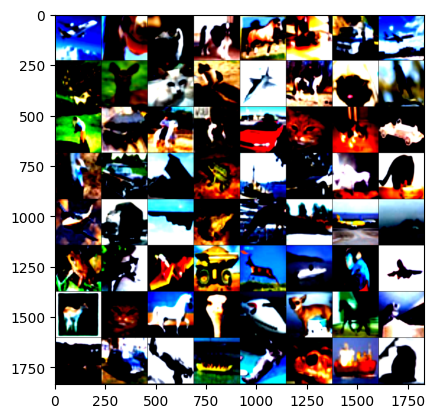

In [3]:
def imshow(img):
    npimg=img.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.show()

# Get somerandom training images
dataiter=iter(train_loader)
images,labels=next(dataiter)
# show images
imshow(torchvision.utils.make_grid(images))


In [4]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.Layer1 = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.Layer2 = nn.Sequential(
            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.Layer3 = nn.Sequential(
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU()
        )
        self.Layer4 = nn.Sequential(
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU()
        )
        self.Layer5 = nn.Sequential(
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(9216, 4096),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Linear(4096, num_classes))
    def forward(self, x):
        out = self.Layer1(x)
        out = self.Layer2(out)
        out = self.Layer3(out)
        out = self.Layer4(out)
        out = self.Layer5(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

In [ ]:
num_classes = 10
num_epochs = 10
batch_size = 64
learning_rate = 0.005

model = AlexNet(num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)         
model.train() 

for epoch in range(num_epochs):  
    running_loss = 0.0
    print(f"Starting Epoch {epoch + 1}/20")

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device) 
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:  # print every 100 batches
            print(f"Epoch {epoch + 1}, Batch {i + 1}/{len(train_loader)}, Loss: {running_loss / (i + 1):.4f}")

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/20] Loss: {avg_loss:.4f}")

print("Finished Training")

Starting Epoch 1/20
Epoch 1, Batch 100/704, Loss: 1.8749
Epoch 1, Batch 200/704, Loss: 1.7029
Epoch 1, Batch 300/704, Loss: 1.6083
Epoch 1, Batch 400/704, Loss: 1.5364
Epoch 1, Batch 500/704, Loss: 1.4753
Epoch 1, Batch 600/704, Loss: 1.4273
Epoch 1, Batch 700/704, Loss: 1.3832
Epoch [1/20] Loss: 1.3812
Starting Epoch 2/20
Epoch 2, Batch 100/704, Loss: 1.0621
Epoch 2, Batch 200/704, Loss: 1.0426
Epoch 2, Batch 300/704, Loss: 1.0362
Epoch 2, Batch 400/704, Loss: 1.0180
Epoch 2, Batch 500/704, Loss: 1.0015
